In [1]:
import os #directory
import requests #url = "https://example.com" function get tipo
from bs4 import BeautifulSoup #webscraping

## Download fake papers

In [2]:
# URL of fake SCIgen papers (all attributed to the fictitious author Ike AntKare)
url= "https://lig-membres.imag.fr/labbe/Publi/IkeAntkare/Ike_AntKare_index.html"

# Directory to store downloaded fake papers
fake_dir = "downloaded_false"
os.makedirs(fake_dir, exist_ok=True) # create if it doesn't exist

In [3]:
# Fetch the webpage content
response = requests.get(url)
response.raise_for_status() # raise an error if the request failed

soup = BeautifulSoup(response.text, 'html.parser') # response.text contains the HTML code of the page (as plain text)
# converts that raw HTML into a structured object (soup) that you can easily search and navigate

In [4]:
# Find all PDF links
pdf_links = [
    a['href']                              # extract the href attribute (the actual link)
    for a in soup.find_all('a', href=True) # iterate over all <a> tags that contain an href
    if a['href'].endswith('.pdf')]         # keep only links ending in ".pdf"

# Note: href = "hypertext reference" (the attribute used for links)

In [5]:
# Iterate over each PDF link found on the page
for link in pdf_links:
  # Handle relative links vs absolute links
  pdf_url = link if link.startswith("http") else f"{url.rsplit('/', 1)[0]}/{link}"
  # Build the local filename (just the PDF name inside the fake_dir folder)
  pdf_name = os.path.join(fake_dir, os.path.basename(link))
  # os.path.basename("path/to/paper1.pdf") -> "paper1.pdf"

  # Download the PDF
  print(f"Downloading {pdf_url}...")
  pdf_response = requests.get(pdf_url)
  pdf_response.raise_for_status()

  # Save the PDF
  with open(pdf_name, 'wb') as file:
    file.write(pdf_response.content)
  print(f"Saved: {pdf_name}")

Saved: downloaded_false/0.pdf
Saved: downloaded_false/1.pdf
Saved: downloaded_false/2.pdf
Saved: downloaded_false/3.pdf
Saved: downloaded_false/4.pdf
Saved: downloaded_false/5.pdf
Saved: downloaded_false/6.pdf
Saved: downloaded_false/7.pdf
Saved: downloaded_false/8.pdf
Saved: downloaded_false/9.pdf
Saved: downloaded_false/10.pdf
Saved: downloaded_false/11.pdf
Saved: downloaded_false/12.pdf
Saved: downloaded_false/13.pdf
Saved: downloaded_false/14.pdf
Saved: downloaded_false/15.pdf
Saved: downloaded_false/16.pdf
Saved: downloaded_false/17.pdf
Saved: downloaded_false/18.pdf
Saved: downloaded_false/19.pdf
Saved: downloaded_false/20.pdf
Saved: downloaded_false/21.pdf
Saved: downloaded_false/22.pdf
Saved: downloaded_false/23.pdf
Saved: downloaded_false/24.pdf
Saved: downloaded_false/25.pdf
Saved: downloaded_false/26.pdf
Saved: downloaded_false/27.pdf
Saved: downloaded_false/28.pdf
Saved: downloaded_false/29.pdf
Saved: downloaded_false/30.pdf
Saved: downloaded_false/31.pdf
Saved: downloaded_

**Extract text from the downloaded fake PDFs**

In [6]:
!pip install PyMuPDF  # PyMuPDF library to extract text from PDF files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 33.6 MB/s eta 0:00:00


In [7]:
import fitz           # PyMuPDF: library to work with PDF files and extract text
import pandas as pd

In [8]:
def extract_text_from_pdf(filepath):
  """
  Extract text from a single PDF file.
  Parameters:
   - filepath: full path to the PDF file
  Returns:
   - string containing all the text from the PDF
  """
  # Open the PDF and combine text from all pages
  try:
    with fitz.open(filepath) as doc:
      return "\n".join([page.get_text() for page in doc])
  except Exception as e:
    # Print an error message if something goes wrong and return empty string
    print(f"Error extracting text from {filepath}: {e}")
    return ""

In [9]:
# Lists to store extracted text and corresponding labels for fake papers
fake_texts = []
fake_labels = []

In [10]:
# Iterate through the PDF files in the fake papers folder
for filename in os.listdir(fake_dir):
  if filename.endswith('.pdf'):
    filepath = os.path.join(fake_dir, filename)
    text = extract_text_from_pdf(filepath)
    if text.strip():          # Check that the extracted text is not empty
      fake_texts.append(text)
      fake_labels.append(0)   # Label 0 for fake papers
    else:
      print(f"[FAKE] Empty or failed to extract text: {filename}")

In [11]:
df_fake = pd.DataFrame({'text': fake_texts, 'label': fake_labels})

In [12]:
print(df_fake.head())

                                                text  label
0  Controlling Telephony Using Unstable Algorithm...      0
1  Analyzing Scatter/Gather I/O and Boolean Logic...      0
2  Reﬁning Markov Models and RPCs\nIke Antkare\nI...      0
3  Investigation of Wide-Area Networks\nIke Antka...      0
4  Towards the Natural Uniﬁcation of Neural\nNetw...      0


## Download true papers

arXiv categories come from: https://arxiv.org/category_taxonomy

In [13]:
!pip install arxiv  # Install the 'arxiv' Python library (to query and download REAL papers from arXiv.org)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.3 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=ee43dacb46bb3a2d3b0fd6e973bfada33da9629b1946f29532b8788273fd32b1
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [14]:
import arxiv    # library to query and download papers from arXiv.org
import random   # for selecting random categories/papers
import shutil   # For high-level file operations
import os

In [15]:
def count_pages(path):
    """Return the number of pages in a PDF"""
    with fitz.open(path) as doc:
        return doc.page_count

def download_random_papers(categories=["cs.NI","cs.DC","cs.OS"],
    true_dir="downloaded_true",
    max_papers=100,    # total number of papers to keep
    max_pages=25,      # maximum pages allowed per paper
    pool_size=200      # number of search results to consider before sampling
):
    """
    Download random papers from arXiv based on multiple categories.
    In particular:
      - "cs.NI" : Networking and Internet Architecture
      - "cs.DC" : Distributed, Parallel, and Cluster Computing
      - "cs.OS" : Operating Systems
    """
    # Delete folder if it exists, then recreate it empty (to avoid errors)
    if os.path.isdir(true_dir):
      shutil.rmtree(true_dir)
    os.makedirs(true_dir, exist_ok=True)

    # Create a client and perform the search
    client = arxiv.Client(page_size=pool_size)                # How many results to fetch at once
    search = arxiv.Search(
        query= " OR ".join([f"cat:{c}" for c in categories]), # Query for multiple categories
        sort_by=arxiv.SortCriterion.SubmittedDate,            # Newest papers first
        max_results=pool_size
    )

    # Execute the search and load results into memory
    results = list(client.results(search))
    if not results:
      print(f"No papers found for categories: {', '.join(categories)}")
      return

    # Shuffle to get a random sample
    random.seed(25)
    random.shuffle(results)

    kept = 0
    files = []
    for r in results:
        if kept >= max_papers:
            break
        try:
            filename = f"{r.get_short_id()}.pdf"
            filepath = os.path.join(true_dir, filename)

            # Skip if already downloaded
            if os.path.exists(filepath):
                print(f"[SKIP] Already exists: {filename}")
                files.append(filepath)
                continue

            # Download PDF
            path = r.download_pdf(dirpath=true_dir)
            pages = count_pages(path)

            # Keep only PDFs with 1–max_pages pages
            if 0 < pages <= max_pages:
                files.append(path)
                kept += 1
                print(f"[OK] Kept: {os.path.basename(path)} ({pages} pages)")
            else:
                os.remove(path)
                print(f"[DROP] {os.path.basename(path)} ({pages} pages)")
        except Exception as e:
            print("Error on", getattr(r, "title", "N/A"), e)

    print(f"\nTotal kept: {len(files)}")
    return files

# Output
download_random_papers(max_papers=100, max_pages=25)


[OK] Kept: 2509.11636v1.Task_Agnostic_Learnable_Weighted_Knowledge_Base_Scheme_for_Robust_Semantic_Communications.pdf (14 pages)
[OK] Kept: 2509.09094v1.Coherence_Aware_Task_Graph_Modeling_for_Realistic_Application.pdf (10 pages)
[OK] Kept: 2509.10533v1.Pair_Bid_Auction_Model_for_Optimized_Network_Slicing_in_5G_RAN.pdf (6 pages)
[OK] Kept: 2509.09493v1.Weaker_Assumptions_for_Asymmetric_Trust.pdf (22 pages)
[OK] Kept: 2509.09997v1.Taming_Volatility__Stable_and_Private_QUIC_Classification_with_Federated_Learning.pdf (5 pages)
[OK] Kept: 2509.08215v1.Design_and_Implementation_of_Code_Completion_System_Based_on_LLM_and_CodeBERT_Hybrid_Subsystem.pdf (6 pages)
[DROP] 2509.10711v1.Asynchronous_Gathering_of_Opaque_Robots_with_Mobility_Faults.pdf (38 pages)
[OK] Kept: 2509.10722v1.Large_Scale_Network_Utility_Maximization_via_GPU_Accelerated_Proximal_Message_Passing.pdf (6 pages)
[OK] Kept: 2509.09058v1.Optimizing_the_Variant_Calling_Pipeline_Execution_on_Human_Genomes_Using_GPU_Enabled_Machines

['downloaded_true/2509.11636v1.Task_Agnostic_Learnable_Weighted_Knowledge_Base_Scheme_for_Robust_Semantic_Communications.pdf',
 'downloaded_true/2509.09094v1.Coherence_Aware_Task_Graph_Modeling_for_Realistic_Application.pdf',
 'downloaded_true/2509.10533v1.Pair_Bid_Auction_Model_for_Optimized_Network_Slicing_in_5G_RAN.pdf',
 'downloaded_true/2509.09493v1.Weaker_Assumptions_for_Asymmetric_Trust.pdf',
 'downloaded_true/2509.09997v1.Taming_Volatility__Stable_and_Private_QUIC_Classification_with_Federated_Learning.pdf',
 'downloaded_true/2509.08215v1.Design_and_Implementation_of_Code_Completion_System_Based_on_LLM_and_CodeBERT_Hybrid_Subsystem.pdf',
 'downloaded_true/2509.10722v1.Large_Scale_Network_Utility_Maximization_via_GPU_Accelerated_Proximal_Message_Passing.pdf',
 'downloaded_true/2509.09058v1.Optimizing_the_Variant_Calling_Pipeline_Execution_on_Human_Genomes_Using_GPU_Enabled_Machines.pdf',
 'downloaded_true/2509.05216v1.Toward_Distributed_3D_Gaussian_Splatting_for_High_Resolution_

**Extract text from the downloaded real PDFs**


In [16]:
# Lists to store extracted text and corresponding labels for real papers
true_texts = []
true_labels = []

In [17]:
# Iterate through the PDF files in the real papers folder
true_dir="downloaded_true"

for filename in os.listdir(true_dir):
  if filename.endswith('.pdf'):
    filepath = os.path.join(true_dir, filename)
    text = extract_text_from_pdf(filepath)
    if text.strip():          # Check that the extracted text is not empty
      true_texts.append(text)
      true_labels.append(1)   # Label 1 for real papers
    else:
      print(f"[REAL] Empty or failed to extract text: {filename}")

In [18]:
# Create a DataFrame for the real papers with columns 'text' and 'label'
df_true = pd.DataFrame({'text': true_texts, 'label': true_labels})

**Combine the real and fake papers DataFrames into a single DataFrame**

In [19]:
df_combined = pd.concat([df_fake, df_true], ignore_index=True)

In [20]:
# Check number of true papers
count_label_1 = (df_combined['label'] == 1).sum()
print("Number of rows with label=1:", count_label_1)

Number of rows with label=1: 100


# **Text pre-processing**

In [21]:
import spacy
import re
import string
from nltk.corpus import stopwords
import nltk

In [22]:
# Load spaCy's English model
nlp = spacy.load("en_core_web_sm")

# Initialize NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [23]:
# Helper function for lemmatization
def lemmatize_text(tokens):
  """Lemmatize each token using spaCy's lemmatizer."""
  # Keep only alphabetic tokens and convert them to their lemma form
  lemmatized_tokens = [token.lemma_ for token in tokens if token.is_alpha]
  return " ".join(lemmatized_tokens)

In [24]:
# Main function for cleaning text
def clean_text_spacy(text):
  """Clean the input text using spaCy for tokenization and lemmatization."""

  # Convert text to lowercase
  text = text.lower()

  # Remove digits
  text = re.sub(r'\d+', '', text)

  # Remove dashes between words
  text = re.sub(r'(?<=\w)[-\u2010\u2011](?=\w)', ' ', text)

  # Remove punctuation
  text = re.sub(r'''[!"#$%&'*+,-./:;<=>?@\[\]^_\{|}~]''', "", text)

  # Tokenize the text using spaCy
  doc = nlp(text)

  # Extract tokens, filtering out stopwords and non-alphabetic tokens
  tokens = [token for token in doc if token.is_alpha and token.text not in stop_words]
  tokens = [token for token in tokens if token not in stop_words and len(token) > 1]

  # Lemmatize the tokens
  cleaned_text = lemmatize_text(tokens)

  return cleaned_text

In [25]:
# Apply the cleaning function
df_combined['cleaned_text'] = df_combined['text'].apply(clean_text_spacy)

In [26]:
# Display the first few rows
df_combined.head()

,text,label,cleaned_text
0,Controlling Telephony Using Unstable Algorithm...,0,controlling telephony use unstable algorithm i...
1,Analyzing Scatter/Gather I/O and Boolean Logic...,0,analyze scattergather io boolean logic sillyle...
2,Reﬁning Markov Models and RPCs\nIke Antkare\nI...,0,reﬁne markov model rpc ike antkare internation...
3,Investigation of Wide-Area Networks\nIke Antka...,0,investigation wide area network ike antkare in...
4,Towards the Natural Uniﬁcation of Neural\nNetw...,0,towards natural uniﬁcation neural network giga...


In [27]:
# Display the last few rows
df_combined.tail()

,text,label,cleaned_text
195,Joint Optimisation of Load Balancing and Energ...,1,joint optimisation load balancing energy effic...
196,Empirical Evaluation of a 5G Transparent Clock...,1,empirical evaluation transparent clock time sy...
197,Introduction to Number Theoretic Transform\nBa...,1,introduction number theoretic transform banhir...
198,IMA Journal of Complex Networks (2025) Page 1 ...,1,journal complex network page doicomnetxxx axio...
199,Trustworthy Second-hand Marketplace for Built ...,1,trustworthy second hand marketplace build envi...


**TEXT CLASSIFICATION**

https://melaniewalsh.github.io/Intro-Cultural-Analytics/05-Text-Analysis/03-TF-IDF-Scikit-Learn.html

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

**TF-IDF + Linear SVM classifier**

In [29]:
X = df_combined["cleaned_text"]
y = df_combined["label"]

# Split data into training and test sets (40% test, stratified by label)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Build a pipeline: TF-IDF vectorization + Linear SVM classifier
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,          # text already lowercased
        tokenizer=str.split,      # split on whitespace
        preprocessor=None,
        token_pattern=None,
        ngram_range=(1,2),        # unigrams and bigrams
        min_df=2,                 # ignore rare tokens
        max_df=0.95,              # ignore very frequent tokens
        norm="l2"
    )),
    ("clf", LinearSVC())         # fast and effective for sparse TF-IDF features
])

# Train the pipeline on the training set
pipe.fit(X_train, y_train)

# Predict on the test set
y_pred = pipe.predict(X_test)

In [30]:
# Evaluate model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [31]:
# Display the distribution of labels in the training and test sets
print(y_train.value_counts())
print(y_test.value_counts())

label
0    60
1    60
Name: count, dtype: int64
label
1    40
0    40
Name: count, dtype: int64


*Accuracy 100%, let's check some parameters*

In [32]:
# Check for overlap between training and test sets (identical documents)
set_train = set(X_train)
set_test = set(X_test)
overlap = len(set_train.intersection(set_test))
print(f"\nOverlap (identical documents in train and test): {overlap}")


Overlap (identical documents in train and test): 0


In [33]:
# F1 scores for each fold and their average
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe, X, y, cv=5, scoring="f1_macro")
print("\nF1 macro per fold:", scores)
print("Media F1:", scores.mean())


F1 macro per fold: [1. 1. 1. 1. 1.]
Media F1: 1.0


**ROC curve - AUC**

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

AUC: 1.0


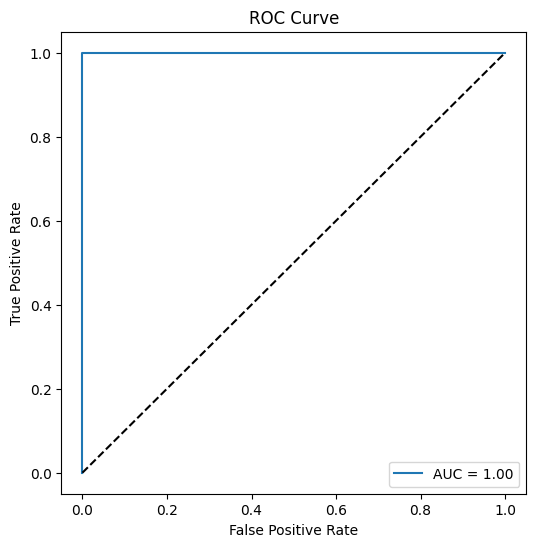

In [35]:
# Get decision scores for test set
y_scores = pipe.decision_function(X_test)  # continuous scores

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC
auc_score = roc_auc_score(y_test, y_scores)
print("AUC:", auc_score)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line for random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Check TF-IDF frequency**

In [36]:
from scipy.sparse import coo_matrix

In [37]:
# Initialize a TF-IDF vectorizer for unigrams and bigrams
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
    ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
)

# Transform the cleaned text into a TF-IDF feature matrix
X_tfidf = tfidf_vectorizer.fit_transform(df_combined["cleaned_text"])

# Get the feature names (terms)
terms = tfidf_vectorizer.get_feature_names_out()

# Use DataFrame index as "document id"
doc_labels = df_combined.index.astype(str)

# Convert the sparse matrix to long format (only non-zero TF-IDF values)
coo = coo_matrix(X_tfidf)
tfidf_long = pd.DataFrame({
    "document": doc_labels[coo.row],
    "term": terms[coo.col],
    "tf-idf": coo.data,
    "label": df_combined["label"].iloc[coo.row].values
})

# For each document, show the top 10 terms by TF-IDF score
tfidf_long.sort_values(by=["document","tf-idf"], ascending=[True, False]).groupby("document").head(10)


,document,term,tf-idf,label
5,0,antkare,0.468880,0
963,0,ike antkare,0.468880,0
4,0,ike,0.466144,0
713,0,proceeding,0.126513,0
708,0,journal,0.094893,0
...,...,...,...,...
239149,99,methodology,0.089431,0
239980,99,november ike,0.056315,0
239416,99,communication,0.053918,0
239518,99,november,0.053467,0


#**Model 2 - Remove most frequent words in fake papers**

In [38]:
# Define custom stopwords to exclude specific words from fake papers (with higher TF-IDF)
custom_stopwords = {"ike", "antkare", "ike antkare"}

In [39]:
# Cleaner version of the text cleaning function
def clean_text_spacy(text):
    """Clean the input text using spaCy, removing standard and custom stopwords, and lemmatizing."""

    # Convert text to lowercase
    text = text.lower()

    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Remove dashes between words
    text = re.sub(r'(?<=\w)[-\u2010\u2011](?=\w)', ' ', text)

    # Remove punctuation
    text = re.sub(r'''[!"#$%&'*+,-./:;<=>?@\[\]^_\{|}~]''', "", text)

    # Tokenize the text using spaCy
    doc = nlp(text)

    # Keep only alphabetic tokens that are not in standard or custom stopwords and have length > 1
    tokens = [token for token in doc if token.is_alpha and
              token.text not in stop_words and
              token.text not in custom_stopwords and
              len(token) > 1]

    # Lemmatize the tokens
    cleaned_text = lemmatize_text(tokens)

    return cleaned_text

In [40]:
df_combined['cleaned_text2'] = df_combined['text'].apply(clean_text_spacy)

In [41]:
# Drop the previous 'cleaned_text' column to replace it with the new cleaned version
df_combined = df_combined.drop(columns=["cleaned_text"])

**TEXT CLASSIFICATION**

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

**TF-IDF + Linear SVM classifier**

In [43]:
X = df_combined["cleaned_text2"]
y = df_combined["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Build a pipeline: TF-IDF vectorization + Linear SVM classifier
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,          # text already lowercased
        tokenizer=str.split,      # split on whitespace
        preprocessor=None,
        token_pattern=None,
        ngram_range=(1,2),        # unigrams and bigrams
        min_df=2,                 # ignore rare tokens
        max_df=0.95,              # ignore very frequent tokens
        norm="l2"
    )),
    ("clf", LinearSVC())         # fast and effective for sparse TF-IDF features
])

# Train the pipeline on the training set
pipe.fit(X_train, y_train)

# Predict on the test set
y_pred = pipe.predict(X_test)

In [44]:
# Evaluate model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**Check TF-IDF frequency**

In [45]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
    ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
)

X_tfidf = tfidf_vectorizer.fit_transform(df_combined["cleaned_text2"])

terms = tfidf_vectorizer.get_feature_names_out()

doc_labels = df_combined.index.astype(str)

coo = coo_matrix(X_tfidf)
tfidf_long = pd.DataFrame({
    "document": doc_labels[coo.row],
    "term": terms[coo.col],
    "tf-idf": coo.data,
    "label": df_combined["label"].iloc[coo.row].values
})

tfidf_long.sort_values(by=["document","tf-idf"], ascending=[True, False]).groupby("document").head(10)

,document,term,tf-idf,label
711,0,proceeding,0.222890,0
706,0,journal,0.167183,0
77,0,methodology,0.109320,0
702,0,ceeding,0.108484,0
1768,0,pro ceeding,0.108484,0
...,...,...,...,...
240631,99,ceeding,0.096723,0
241018,99,pro ceeding,0.096723,0
240634,99,february,0.091010,0
240674,99,june,0.086531,0


***OTHER CLASSIFICATION MODELS***

**Logistic regression**

In [46]:
from sklearn.linear_model import LogisticRegression

pipe_log = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", LogisticRegression(penalty="l2", solver="liblinear", random_state=42))
])

pipe_log.fit(X_train, y_train)
y_pred = pipe_log.predict(X_test)

In [47]:
# Evaluate LOGISTIC model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**Naive bayes**

In [48]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        tokenizer=str.split, preprocessor=None, token_pattern=None,
        analyzer="word",
        ngram_range=(1,2),
        min_df=2, max_df=0.95,
        norm="l2"
    )),
    ("clf", MultinomialNB())
])

pipe_nb.fit(X_train, y_train)
y_pred = pipe_nb.predict(X_test)

In [49]:
# Evaluate NAIVE model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**Random Forest**

In [50]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred = pipe_rf.predict(X_test)

In [51]:
# Evaluate RANDOM FOREST model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**COMPARING CLASSIFIER MODEL 2**

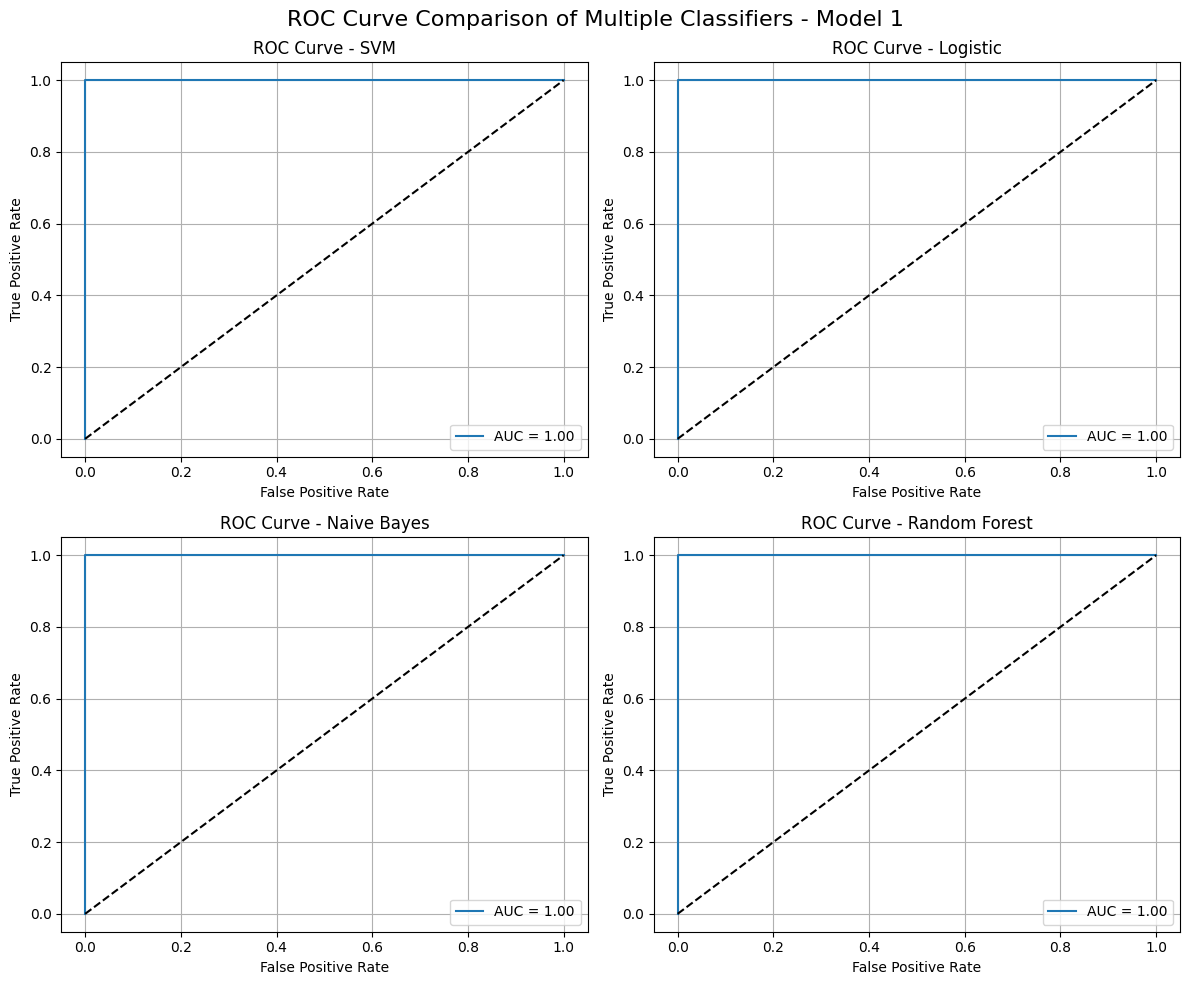

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Dictionary of trained models to compare
models = {
    "SVM": pipe,              # SVM pipeline
    "Logistic": pipe_log,     # Logistic Regression pipeline
    "Naive Bayes": pipe_nb,   # Naive Bayes pipeline
    "Random Forest": pipe_rf  # Random Forest pipeline
}

# Create side-by-side subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    # Get prediction scores
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)

    # Plot ROC curve
    ax.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    ax.plot([0, 1], [0, 1], 'k--')

    ax.set_title(f"ROC Curve - {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("ROC Curve Comparison of Multiple Classifiers - Model 1", fontsize=16)
plt.tight_layout()
plt.show()

# **Model 3 - structure of the text**

In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

**TF-IDF + linear SVM classifier**

In [70]:
# Search for fixed sentence structures --> N-GRAM
X = df_combined["cleaned_text2"].astype(str)
y = df_combined["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,           # Do not lowercase text
        tokenizer=str.split,       # Split on spaces
        preprocessor=None,
        token_pattern=None,
        analyzer="word",
        ngram_range=(2,5),         # Consider 2 to 5 N-grams
        min_df=2, max_df=0.95,     # Ignore rare and very frequent terms
        norm="l2"                  # L2 normalization
    )),
    ("clf", LinearSVC())           # Linear SVM classifier
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

In [71]:
# Evaluate model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**Check frequency**

In [72]:
# Extract trained TF-IDF vectorizer and classifier
vec = pipe.named_steps["tfidf"]
clf = pipe.named_steps["clf"]
feature_names = np.array(vec.get_feature_names_out())

# Get class order and coefficients
classes = clf.classes_
coefs = clf.coef_[0]

# Order features by weight
order_pos = np.argsort(coefs)[::-1]  # Top positive weights (favor real)
order_neg = np.argsort(coefs)        # Top negative weights (favor fake)

top_k = 15
# Top n-grams for real class
top_real = pd.DataFrame({
    "ngram": feature_names[order_pos][:top_k],
    "weight": coefs[order_pos][:top_k]
})

# Top n-grams for fake class
top_fake = pd.DataFrame({
    "ngram": feature_names[order_neg][:top_k],
    "weight": coefs[order_neg][:top_k]
})

# Display results
print("TOP n-grams for REAL (label=1)")
display(top_real)

print("\n TOP n-grams for FAKE (label=0)")
display(top_fake)

TOP n-grams for REAL (label=1)


,ngram,weight
0,vol pp,0.208126
1,ipv address,0.123427
2,batch size,0.122926
3,high performance,0.115872
4,ue antenna,0.104470
5,quantum network,0.097916
6,international conference,0.095163
7,real world,0.091634
8,end end,0.089868
9,control system,0.089447



 TOP n-grams for FAKE (label=0)


,ngram,weight
0,proceeding workshop,-0.268824
1,pro ceeding,-0.246797
2,proceeding conference,-0.228366
3,consider harmful,-0.219000
4,gigabit switch,-0.191527
5,context free,-0.187862
6,cache coherence,-0.182612
7,technical report,-0.176043
8,context free grammar,-0.156652
9,free grammar,-0.156652


**SHAP**

In [73]:
import shap
import matplotlib.pyplot as plt

In [74]:
# Transform the test set with TF-IDF
X_test_tfidf = pipe.named_steps["tfidf"].transform(X_test)
X_test_dense = X_test_tfidf.toarray()  # required for SHAP

feature_names = pipe.named_steps["tfidf"].get_feature_names_out()
clf = pipe.named_steps["clf"]

# SHAP explainer for LinearSVC
explainer = shap.LinearExplainer(clf, X_test_dense, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_dense)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


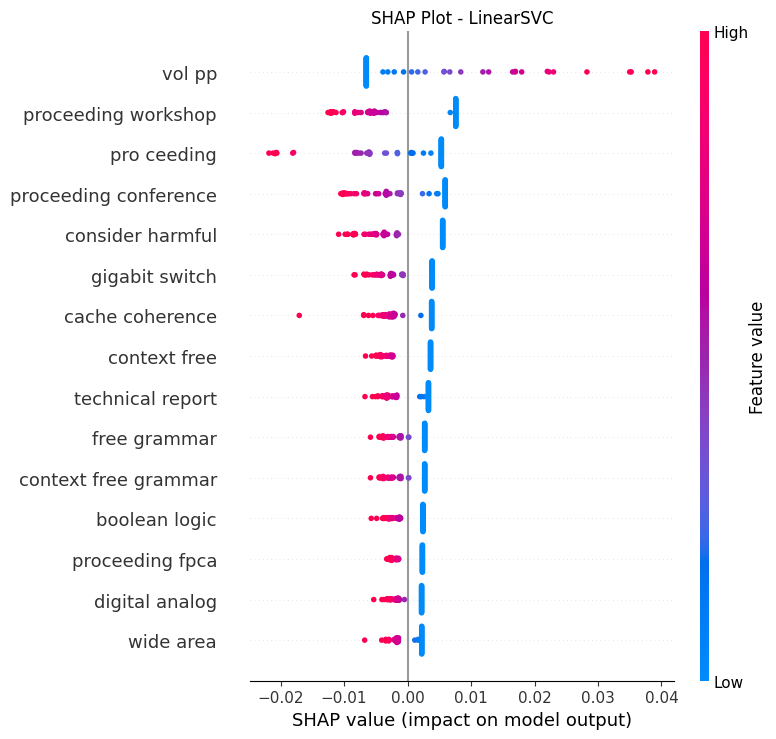

In [75]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    show=False,
    max_display=15
)
plt.title("SHAP Plot - LinearSVC")
plt.tight_layout()
plt.show()

***OTHER CLASSIFICATION MODEL***

**Logistic regression**

In [57]:
from sklearn.linear_model import LogisticRegression

pipe_log = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split,
        preprocessor=None, token_pattern=None,
        analyzer="word",
        ngram_range=(2,5),
        min_df=2, max_df=0.95,
        norm="l2"
    )),
    ("clf", LogisticRegression(max_iter=200))
])

pipe_log.fit(X_train, y_train)
y_pred = pipe_log.predict(X_test)

In [58]:
# Evaluate LOGISTIC model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**Naive Bayes**

In [59]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        tokenizer=str.split, preprocessor=None, token_pattern=None,
        analyzer="word",
        ngram_range=(1,2),
        min_df=2, max_df=0.95,
        norm="l2"
    )),
    ("clf", MultinomialNB())
])

pipe_nb.fit(X_train, y_train)
y_pred = pipe_nb.predict(X_test)

In [60]:
# Evaluate NAIVE model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**Random forest**

In [61]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, tokenizer=str.split, preprocessor=None, token_pattern=None,
        ngram_range=(1,2), min_df=2, max_df=0.95, norm="l2"
    )),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred = pipe_rf.predict(X_test)

In [62]:
# Evaluate RANDOM FOREST model performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[40  0]
 [ 0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**COMPARING CLASSIFIER MODEL 3**

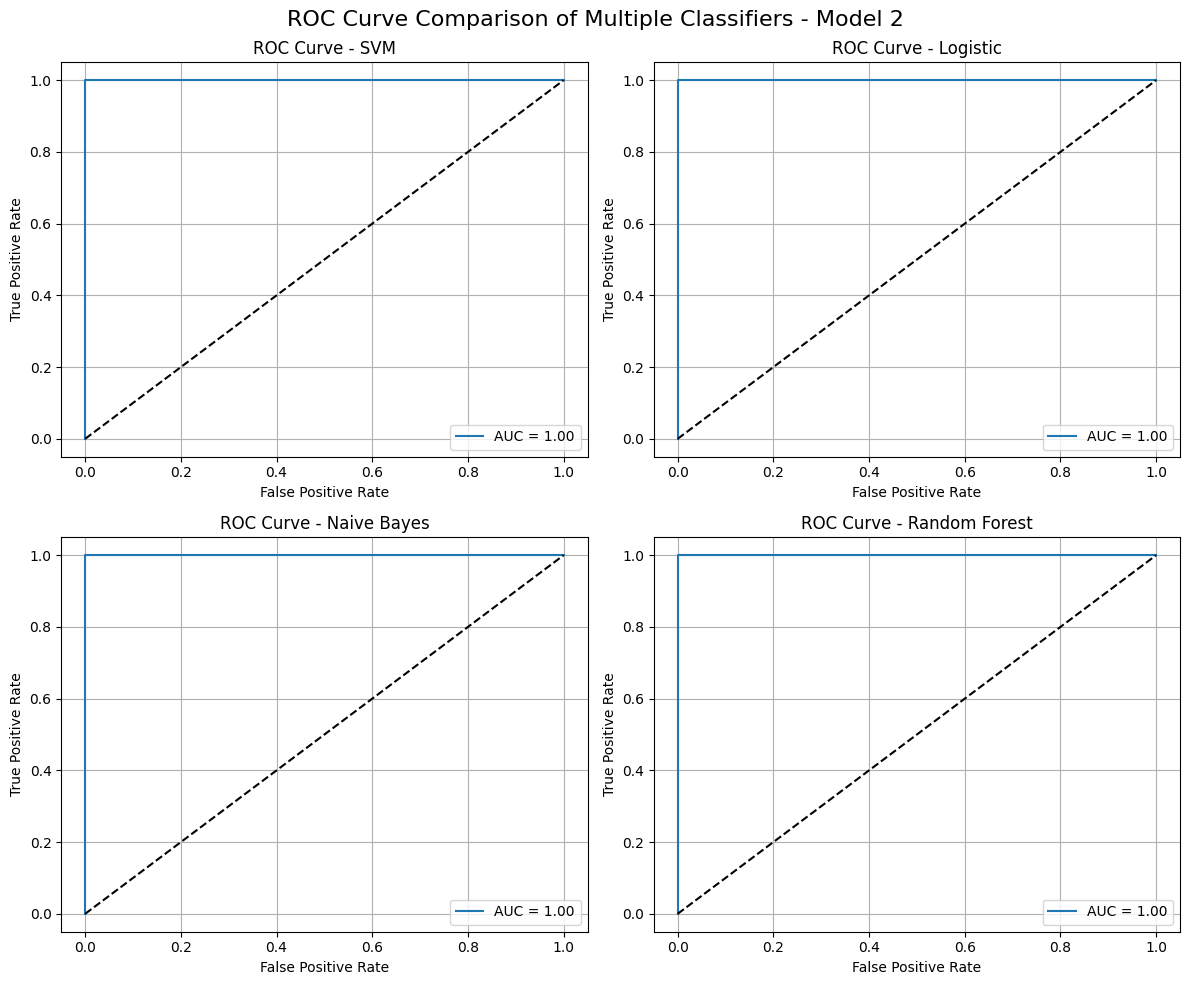

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Dictionary of trained models to compare
models = {
    "SVM": pipe,              # SVM pipeline
    "Logistic": pipe_log,     # Logistic Regression pipeline
    "Naive Bayes": pipe_nb,   # Naive Bayes pipeline
    "Random Forest": pipe_rf  # Random Forest pipeline
}

# Create side-by-side subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    # Get prediction scores
    if hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)

    # Plot ROC curve
    ax.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    ax.plot([0, 1], [0, 1], 'k--')

    ax.set_title(f"ROC Curve - {name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("ROC Curve Comparison of Multiple Classifiers - Model 2", fontsize=16)
plt.tight_layout()
plt.show()